In [1]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

## Load Test Data

Load a small subset (first 20 time steps) from PINACLES 600x600 simulation.

In [2]:
# Load only the first part file for testing
ds_2d1 = xr.open_dataset('/pscratch/sd/p/paccini/temp/temp_imse_budget/ds_2d_600x600_3km_SCREAMinit_part1.nc')

# Select only first 20 time steps for quick testing
ds_2d_test = ds_2d1.isel(time=slice(0, 50))
model_2d_olr = ds_2d_test.toa_lw_up.copy()

print(f"Test data shape: {model_2d_olr.shape}")
print(f"Time range: {model_2d_olr.time.values[0]} to {model_2d_olr.time.values[-1]}")

Test data shape: (50, 200, 200)
Time range: 2000-01-01T00:00:00.000000000 to 2000-01-03T01:00:00.000000000


## Import Both Implementations

In [3]:
# Import original periodic implementation
from run_metrics_periodic import run_metrics_periodic as run_metrics_original

# Import fixed periodic implementation  
from run_metrics_periodic_fixed import run_metrics_periodic as run_metrics_fixed

## Visual Inspection of Sample Time Step

Let's visualize a few time steps to see the convective organization.

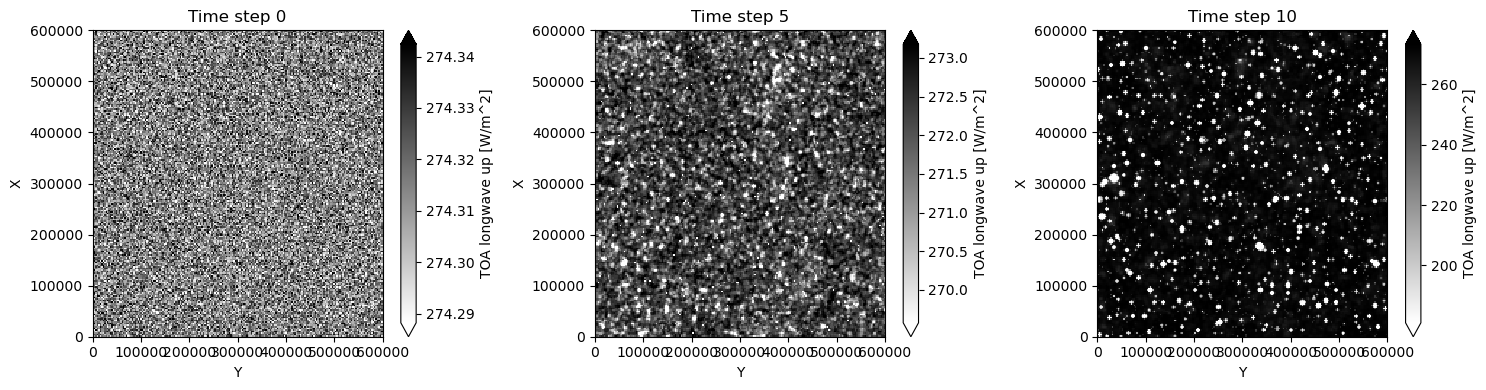

In [4]:
# Plot a few sample time steps
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, time_idx in enumerate([0, 5, 10]):
    model_2d_olr.isel(time=time_idx).plot(ax=axes[i], robust=True, cmap='gray_r')
    axes[i].set_title(f'Time step {time_idx}')
plt.tight_layout()

## Run Both Implementations and Compare

In [5]:
def process_comparison(ds, time_coord='time', cut=173):
    """
    Process the same data with both original and fixed periodic implementations.
    """
    df_original = pd.DataFrame()
    df_fixed = pd.DataFrame()
    
    time_values = ds.coords[time_coord].values
    
    for time_value in time_values:
        ds_time = ds.sel({time_coord: time_value})
        
        # Extract datetime info
        date_time = pd.to_datetime(str(time_value))
        yy, mm, dd, hh, mi = date_time.year, date_time.month, date_time.day, date_time.hour, date_time.minute
        
        df_time_tmp = pd.DataFrame({
            'year': [yy], 'month': [mm], 'day': [dd], 'hour': [hh], 'minute': [mi]
        })
        
        # Convert to binary image based on OLR threshold
        image = np.where(ds_time.data < cut, 1, 0).astype(int)
        
        # Run ORIGINAL periodic implementation
        dict_org_original = run_metrics_original(np.copy(image))
        df_org_tmp = pd.DataFrame(dict_org_original, index=[0])
        df_tmp_original = pd.concat([df_time_tmp.reset_index(drop=True), df_org_tmp.reset_index(drop=True)], axis=1)
        df_original = pd.concat([df_original, df_tmp_original], ignore_index=True)
        
        # Run FIXED periodic implementation
        dict_org_fixed = run_metrics_fixed(np.copy(image))
        df_org_tmp = pd.DataFrame(dict_org_fixed, index=[0])
        df_tmp_fixed = pd.concat([df_time_tmp.reset_index(drop=True), df_org_tmp.reset_index(drop=True)], axis=1)
        df_fixed = pd.concat([df_fixed, df_tmp_fixed], ignore_index=True)
    
    return df_original, df_fixed

In [6]:
# Run comparison
print("Running original implementation...")
df_original, df_fixed = process_comparison(model_2d_olr)
print("✓ Complete!")

Running original implementation...
✓ Complete!


In [7]:
# Add time column for plotting
df_original['time'] = model_2d_olr.time.values
df_fixed['time'] = model_2d_olr.time.values

## Comparison Results

### Key Metrics to Compare:
- **Number of objects**: Should be LOWER in fixed version when periodic wrapping is corrected
- **Mean area**: Should be LARGER in fixed version (objects properly merged)
- **Iorg**: Organization index should be more stable (fewer artificial drops)

In [8]:
# Summary statistics
print("="*70)
print("COMPARISON SUMMARY")
print("="*70)
print("\nNumber of Objects:")
print(f"  Original: mean={df_original['number'].mean():.1f}, std={df_original['number'].std():.2f}")
print(f"  Fixed:    mean={df_fixed['number'].mean():.1f}, std={df_fixed['number'].std():.2f}")
print(f"  → Change: {df_fixed['number'].mean() - df_original['number'].mean():.1f} objects")

print("\nMean Object Area:")
print(f"  Original: mean={df_original['mean_area'].mean():.1f}")
print(f"  Fixed:    mean={df_fixed['mean_area'].mean():.1f}")
print(f"  → Change: {((df_fixed['mean_area'].mean() / df_original['mean_area'].mean()) - 1) * 100:.1f}%")

print("\nIorg (Organization Index):")
print(f"  Original: mean={df_original['Iorg'].mean():.3f}, std={df_original['Iorg'].std():.3f}")
print(f"  Fixed:    mean={df_fixed['Iorg'].mean():.3f}, std={df_fixed['Iorg'].std():.3f}")

print("\n" + "="*70)

COMPARISON SUMMARY

Number of Objects:
  Original: mean=163.2, std=76.40
  Fixed:    mean=163.0, std=76.28
  → Change: -0.2 objects

Mean Object Area:
  Original: mean=8.6
  Fixed:    mean=8.7
  → Change: 0.1%

Iorg (Organization Index):
  Original: mean=0.403, std=0.029
  Fixed:    mean=0.403, std=0.029



## Visual Comparison Plots

Compare key metrics between original and fixed implementations.

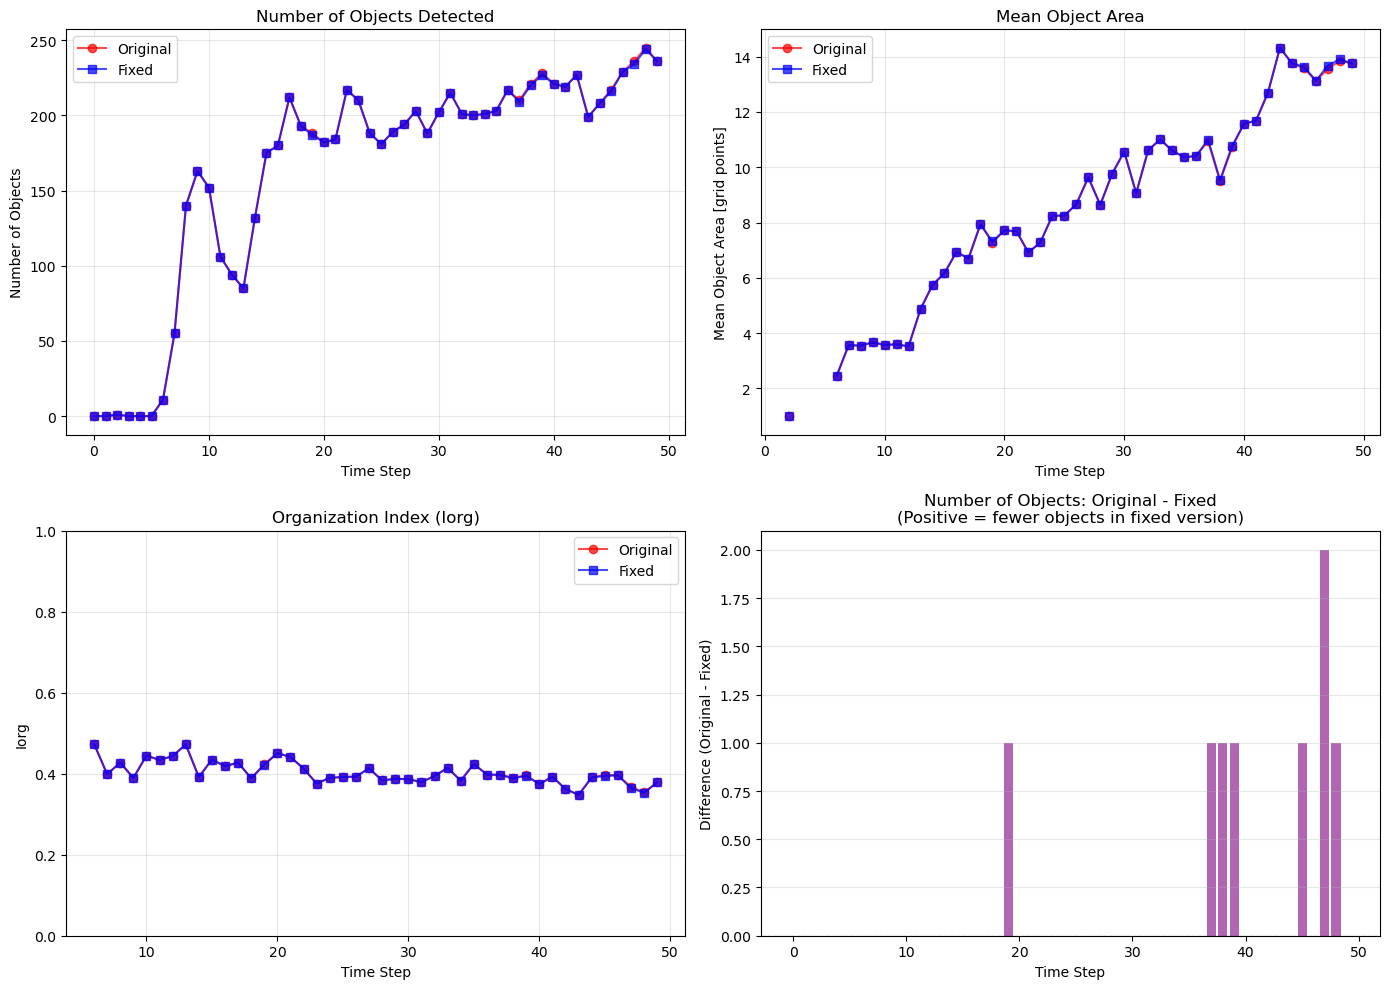

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Number of objects
axes[0, 0].plot(df_original.index, df_original['number'], 'o-', color='red', alpha=0.7, label='Original')
axes[0, 0].plot(df_fixed.index, df_fixed['number'], 's-', color='blue', alpha=0.7, label='Fixed')
axes[0, 0].set_xlabel('Time Step')
axes[0, 0].set_ylabel('Number of Objects')
axes[0, 0].set_title('Number of Objects Detected')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Mean area
axes[0, 1].plot(df_original.index, df_original['mean_area'], 'o-', color='red', alpha=0.7, label='Original')
axes[0, 1].plot(df_fixed.index, df_fixed['mean_area'], 's-', color='blue', alpha=0.7, label='Fixed')
axes[0, 1].set_xlabel('Time Step')
axes[0, 1].set_ylabel('Mean Object Area [grid points]')
axes[0, 1].set_title('Mean Object Area')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Iorg
axes[1, 0].plot(df_original.index, df_original['Iorg'], 'o-', color='red', alpha=0.7, label='Original')
axes[1, 0].plot(df_fixed.index, df_fixed['Iorg'], 's-', color='blue', alpha=0.7, label='Fixed')
axes[1, 0].set_xlabel('Time Step')
axes[1, 0].set_ylabel('Iorg')
axes[1, 0].set_title('Organization Index (Iorg)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim(0, 1)

# Plot 4: Difference in number of objects
diff_number = df_original['number'] - df_fixed['number']
axes[1, 1].bar(df_original.index, diff_number, color='purple', alpha=0.6)
axes[1, 1].axhline(y=0, color='k', linestyle='--', linewidth=0.8)
axes[1, 1].set_xlabel('Time Step')
axes[1, 1].set_ylabel('Difference (Original - Fixed)')
axes[1, 1].set_title('Number of Objects: Original - Fixed\n(Positive = fewer objects in fixed version)')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Detailed Comparison Table

Show side-by-side values for selected metrics.

In [10]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Time_Step': df_original.index,
    'N_Objects_Original': df_original['number'],
    'N_Objects_Fixed': df_fixed['number'],
    'Diff_N_Objects': df_original['number'] - df_fixed['number'],
    'Iorg_Original': df_original['Iorg'].round(3),
    'Iorg_Fixed': df_fixed['Iorg'].round(3),
    'MeanArea_Original': df_original['mean_area'].round(1),
    'MeanArea_Fixed': df_fixed['mean_area'].round(1),
})

print("\nDetailed Comparison (first 10 time steps):")
print(comparison_df.tail(10).to_string(index=False))


Detailed Comparison (first 10 time steps):
 Time_Step  N_Objects_Original  N_Objects_Fixed  Diff_N_Objects  Iorg_Original  Iorg_Fixed  MeanArea_Original  MeanArea_Fixed
         0                   0                0               0            NaN         NaN                NaN             NaN
         1                   0                0               0            NaN         NaN                NaN             NaN
         2                   1                1               0            NaN         NaN                1.0             1.0
         3                   0                0               0            NaN         NaN                NaN             NaN
         4                   0                0               0            NaN         NaN                NaN             NaN
         5                   0                0               0            NaN         NaN                NaN             NaN
         6                  11               11               0          0

## Interpretation

**Expected improvements in FIXED version:**

1. **Fewer objects detected**: When objects wrap around periodic boundaries, the original version incorrectly splits them into multiple objects. The fixed version should show fewer total objects.

2. **Larger mean area**: Since wrapped objects are now correctly identified as single objects, the mean area per object should increase.

3. **More stable Iorg**: Sudden drops in Iorg often occur when large organized structures get artificially split by boundary issues. The fixed version should show smoother transitions.

4. **Positive differences**: Time steps showing `Diff_N_Objects > 0` indicate cases where the original version incorrectly split objects across boundaries.

**If the fixed version shows significantly different results, this confirms the periodic boundary handling was the source of your sudden drops in organization indices.**

## Next Steps

If the fixed implementation shows improvements:
1. Replace `run_metrics_periodic` imports with `run_metrics_periodic_fixed` in your analysis notebooks
2. Reprocess your full datasets with the corrected implementation
3. The sudden drops in Iorg should be reduced or eliminated